# Section 1 - Loading Data, Models and Labels

## 1.1 -  Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import random
import torch
import joblib
import json
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


## 1.2 -  Path Setup

In [5]:
import sys
from pathlib import Path

# Define the Root (at SCANIA COMPONENT X)
PROJECT_ROOT = Path.cwd().parent

# Data Directory (Matches your "Data/Processed Data" folder exactly)
DATA_DIR = PROJECT_ROOT / "Data" / "Processed Data"

# Results Hierarchy
RESULTS_DIR = PROJECT_ROOT / "Results"
MODEL_DIR = RESULTS_DIR / "Models"
PREDICTION_DIR = RESULTS_DIR / "Predictions"

# Adding root to sys.path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Diagnostic Prints
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")
print(f"Model Path:   {MODEL_DIR}")
print(f"Predictions:  {PREDICTION_DIR}")

# Test if we can see the data file aka. if the path set-up is correct and the file exists
test_file = DATA_DIR / "val_processed.csv"

if test_file.exists():
    print(f"Success! Found {test_file}")
else:
    raise FileNotFoundError(f"Missing expected file: {test_file}")


Project Root: c:\Users\Elias\Documents\SCANIA Component X
Data Source:  c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data
Model Path:   c:\Users\Elias\Documents\SCANIA Component X\Results\Models
Predictions:  c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions
Success! Found c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data\val_processed.csv


In [6]:
import importlib
import utils

importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Elias\\Documents\\SCANIA Component X\\utils\\__init__.py'>

## 1.3 - Data Loading




In [7]:
# Loading the Test data
test_data = pd.read_csv(DATA_DIR / 'test_processed.csv')

test_data.head()

,vehicle_id,time_step,label,171_0_delta,666_0_delta,427_0_delta,837_0_delta,167_0_delta,167_1_delta,167_2_delta,...,397_26_delta,397_27_delta,397_28_delta,397_29_delta,397_30_delta,397_31_delta,397_32_delta,397_33_delta,397_34_delta,397_35_delta
0,1,4.4,0,-0.849629,-0.749216,-0.885264,-0.605540,0.000000,-0.836789,-0.846661,...,-0.819951,-0.736580,-0.604093,-0.117108,-0.683286,-0.774069,-0.802742,-0.765314,-0.643327,-0.220868
1,1,5.0,0,-0.151508,-0.053570,-0.131259,0.062950,0.076528,-0.121663,-0.188505,...,-0.083976,-0.006910,0.039970,-0.117108,-0.196052,-0.080403,-0.033903,-0.051278,-0.124673,-0.220868
2,1,8.2,0,0.020609,0.188996,0.006269,0.279719,0.903871,-0.046302,-0.068225,...,0.105294,0.161388,0.205492,0.340419,0.100194,0.146245,0.154085,0.176175,0.200408,0.064500
3,1,9.8,0,-0.044547,0.100857,-0.041502,0.273653,0.815721,-0.101015,-0.100659,...,0.032982,0.090441,0.123136,0.451799,0.032256,0.073004,0.091633,0.119043,0.162627,0.203325
4,1,20.6,0,0.085687,0.258765,0.057940,0.425123,0.773686,0.016771,0.002164,...,0.169083,0.227552,0.324460,0.693144,0.249081,0.195126,0.206377,0.241012,0.304689,0.658141


In [50]:
# Loading the saved predictions for the validation set
lr_preds = pd.read_csv(PREDICTION_DIR / 'lr_val_predictions.csv')
lstm_preds = pd.read_csv(PREDICTION_DIR / 'lstm_val_predictions.csv')
tcn_preds = pd.read_csv(PREDICTION_DIR / 'tcn_val_predictions.csv')
smote_lr_preds = pd.read_csv(PREDICTION_DIR / 'smote_lr_val_predictions.csv')
smote_xgb_preds = pd.read_csv(PREDICTION_DIR / 'smote_xgb_val_predictions.csv')

# Loading the true labels for the validation set
val_labels = pd.read_csv(PROJECT_ROOT / "Data" / 'validation_labels.csv')
test_labels = pd.read_csv(PROJECT_ROOT / "Data" / 'test_labels.csv')

# Merging predictions with true labels on 'vehicle_id' to ensure alignment for metric calculations
lr_preds = lr_preds.merge(val_labels, on='vehicle_id')
lstm_preds = lstm_preds.merge(val_labels, on='vehicle_id')
tcn_preds = tcn_preds.merge(val_labels, on='vehicle_id')
smote_lr_preds = smote_lr_preds.merge(val_labels, on='vehicle_id')
smote_xgb_preds = smote_xgb_preds.merge(val_labels, on='vehicle_id')

# Importing the hyperparameters used for the models
with open(MODEL_DIR / 'hyperparams.json', 'r') as f:
    hp = json.load(f)


with open(PREDICTION_DIR / 'cost_results.json', 'r') as f:
    cost_results = json.load(f)
optimal_thresholds = {name: cost_results[name]['threshold'] for name in cost_results}

# Double check the structure of the merged DataFrames to ensure they contain the expected columnsp
print(lr_preds.columns.tolist())
print(lr_preds['class_label'].value_counts().sort_index())


['vehicle_id', 'probability', 'binary_prediction', 'class_label']
class_label
0    4910
1      16
2      14
3      30
4      76
Name: count, dtype: int64


## 1.4 Making the Cost Matrix
The cost Matrix is described [here](https://www.nature.com/articles/s41597-025-04802-6), in this section we define it and set it to a form that we can work with. In this case we are choosing to set it as (actual class , predicted class) as well as its cost. The actual class is derived from the 5-labeled metrics cointained in the raw data, while the predicted class consists of the binary label created in the data preprocessing notebook.



In [9]:
# Cost matrix where keys are (actual_class, predicted_class)
SCANIA_COST = {
    (0,0):0,   (0,1):7,   (0,2):8,   (0,3):9,   (0,4):10,
    (1,0):200, (1,1):0,   (1,2):7,   (1,3):8,   (1,4):9,
    (2,0):300, (2,1):200, (2,2):0,   (2,3):7,   (2,4):8,
    (3,0):400, (3,1):300, (3,2):200, (3,3):0,   (3,4):7,
    (4,0):500, (4,1):400, (4,2):300, (4,3):200, (4,4):0,
}
# Checking that the cost matrix is correctly defined and that the compute_total_cost function works as expected
print(utils.compute_total_cost([4], [0], SCANIA_COST))  # Should return 500 (false negative)
print(utils.compute_total_cost([0], [1], SCANIA_COST))  # Should return 7   (false positive)
print(utils.compute_total_cost([0], [0], SCANIA_COST))  # Should return 0   (true negative)
print(utils.compute_total_cost([1], [1], SCANIA_COST))  # Should return 0   (true positive)

500
7
0
0


# Section 2 - Validation: Standard Metric Evaluation


## 2.1 - Comparison on Default Treshold
In this project, the default threshold is 0.5.

In [11]:
comparison = pd.DataFrame({
    'LR':        utils.get_metrics(lr_preds),
    'LSTM':      utils.get_metrics(lstm_preds),
    'TCN':       utils.get_metrics(tcn_preds),
    'SMOTE-LR':  utils.get_metrics(smote_lr_preds),
    'SMOTE-XGB': utils.get_metrics(smote_xgb_preds),
})
print(comparison.round(4))

               LR    LSTM     TCN  SMOTE-LR  SMOTE-XGB
Recall     0.7500  0.2574  0.4044    0.8088     0.5735
Precision  0.0400  0.0753  0.0498    0.0392     0.0363
F1         0.0759  0.1165  0.0887    0.0749     0.0683
AUC-ROC    0.6925  0.6616  0.6759    0.6856     0.6241
AUC-PR     0.0647  0.0638  0.0545    0.0706     0.0445


## 2.2 - F1 vs. Threshold

LR — optimal threshold: 0.87, max F1: 0.1212
LSTM — optimal threshold: 0.50, max F1: 0.1165
TCN — optimal threshold: 0.58, max F1: 0.1028
SMOTE-LR — optimal threshold: 0.92, max F1: 0.1224
SMOTE-XGB — optimal threshold: 0.77, max F1: 0.0877


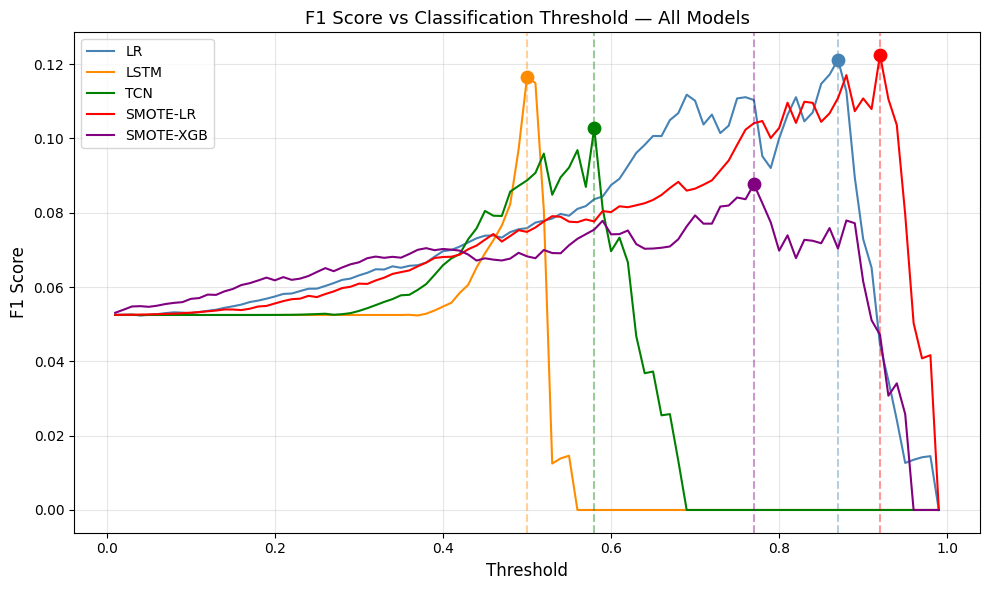

In [12]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.01, 1.0, 0.01)
models = {
    'LR':        lr_preds,
    'LSTM':      lstm_preds,
    'TCN':       tcn_preds,
    'SMOTE-LR':  smote_lr_preds,
    'SMOTE-XGB': smote_xgb_preds,
}

colors = {
    'LR':        'steelblue',
    'LSTM':      'darkorange',
    'TCN':       'green',
    'SMOTE-LR':  'red',
    'SMOTE-XGB': 'purple'
}

f1_by_threshold = {}
for name, df in models.items():
    f1s = []
    for t in thresholds:
        y_true_binary = (df['class_label'].values > 0).astype(int)
        y_pred = (df['probability'].values >= t).astype(int)
        f1s.append(f1_score(y_true_binary, y_pred, zero_division=0))
    f1_by_threshold[name] = f1s

# Find optimal threshold per model
for name, f1s in f1_by_threshold.items():
    best_idx = np.argmax(f1s)
    print(f"{name} — optimal threshold: {thresholds[best_idx]:.2f}, max F1: {f1s[best_idx]:.4f}")

plt.figure(figsize=(10, 6))
for name, f1s in f1_by_threshold.items():
    best_idx = np.argmax(f1s)
    plt.plot(thresholds, f1s, label=name, color=colors[name])
    plt.axvline(x=thresholds[best_idx], color=colors[name],
                linestyle='--', alpha=0.4)
    plt.scatter(thresholds[best_idx], f1s[best_idx],
                color=colors[name], zorder=5, s=80)

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Score vs Classification Threshold — All Models', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.3 - F2 vs Threshold

LR — optimal threshold: 0.69, max F2: 0.2061
LSTM — optimal threshold: 0.50, max F2: 0.1734
TCN — optimal threshold: 0.48, max F2: 0.1742
SMOTE-LR — optimal threshold: 0.76, max F2: 0.1864
SMOTE-XGB — optimal threshold: 0.59, max F2: 0.1578


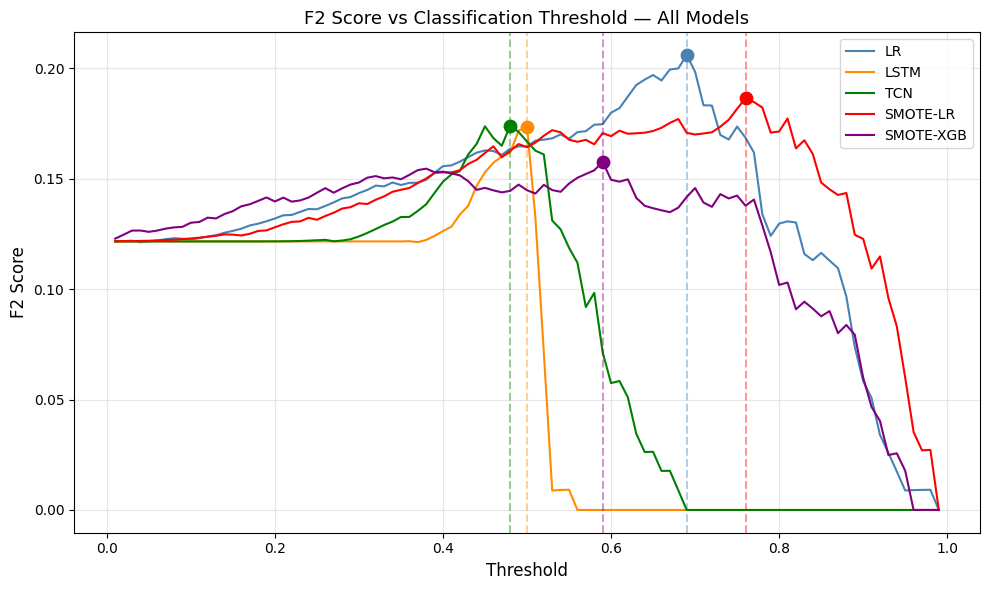

In [15]:
from sklearn.metrics import fbeta_score

fbeta_by_threshold = {}
for name, df in models.items():
    scores = []
    for t in thresholds:
        y_true_binary = (df['class_label'].values > 0).astype(int)
        y_pred = (df['probability'].values >= t).astype(int)
        scores.append(fbeta_score(y_true_binary, y_pred, beta=2, zero_division=0))
    fbeta_by_threshold[name] = scores

for name, scores in fbeta_by_threshold.items():
    best_idx = np.argmax(scores)
    print(f"{name} — optimal threshold: {thresholds[best_idx]:.2f}, max F2: {scores[best_idx]:.4f}")

plt.figure(figsize=(10, 6))
for name, scores in fbeta_by_threshold.items():
    best_idx = np.argmax(scores)
    plt.plot(thresholds, scores, label=name, color=colors[name])
    plt.axvline(x=thresholds[best_idx], color=colors[name],
                linestyle='--', alpha=0.4)
    plt.scatter(thresholds[best_idx], scores[best_idx],
                color=colors[name], zorder=5, s=80)

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F2 Score', fontsize=12)
plt.title('F2 Score vs Classification Threshold — All Models', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.3 - Comparison at Optimal Threshold

In [51]:
import pandas as pd
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score



models = {
    'LR':        lr_preds,
    'LSTM':      lstm_preds,
    'TCN':       tcn_preds,
    'SMOTE+LR':  smote_lr_preds,
    'SMOTE+XGB': smote_xgb_preds,
}

with open(PREDICTION_DIR / 'cost_results.json', 'r') as f:
    cost_results = json.load(f)
optimal_thresholds = {name: cost_results[name]['threshold'] for name in cost_results}

def get_metrics_at_threshold(preds_df, threshold):
    y_true = (preds_df['class_label'] > 0).astype(int)
    y_pred = (preds_df['probability'] >= threshold).astype(int)
    y_pred_class = y_pred * 4
    y_true_class = preds_df['class_label'].values
    cost = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(y_true_class, y_pred_class))
    return {
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_true, preds_df['probability']),
        'AUC-PR':    average_precision_score(y_true, preds_df['probability']),
        'Cost':      cost,
        'Threshold': threshold,
    }

comparison_optimal = pd.DataFrame({
    name: get_metrics_at_threshold(df, optimal_thresholds[name])
    for name, df in models.items()
})
print(comparison_optimal.round(4))

                   LR        LSTM         TCN    SMOTE+LR   SMOTE+XGB
Recall         0.5662      0.7059      0.7647      0.7941      0.7647
Precision      0.0538      0.0383      0.0425      0.0416      0.0367
F1             0.0983      0.0726      0.0805      0.0791      0.0700
AUC-ROC        0.6925      0.6616      0.6759      0.6856      0.6241
AUC-PR         0.0647      0.0638      0.0545      0.0706      0.0445
Cost       36642.0000  40206.0000  36477.0000  36721.0000  40319.0000
Threshold      0.6400      0.4600      0.4500      0.5300      0.3700


# Section 3 - Validation: Cost-Based Evaluation 

## 3.1 - Comparison Table With Total Costs per Model

In [18]:
models = {
    'LR':        lr_preds,
    'LSTM':      lstm_preds,
    'TCN':       tcn_preds,
    'SMOTE-LR':  smote_lr_preds,
    'SMOTE-XGB': smote_xgb_preds,
}

costs_at_default = {}
for name, df in models.items():
    y_true = df['class_label'].values
    y_pred = (df['probability'].values >= 0.5).astype(int)
    costs_at_default[name] = utils.compute_total_cost(y_true, y_pred, SCANIA_COST)

comparison.loc['Cost'] = costs_at_default
print(comparison.round(4))

                   LR        LSTM         TCN    SMOTE-LR   SMOTE-XGB
Recall         0.7500      0.2574      0.4044      0.8088      0.5735
Precision      0.0400      0.0753      0.0498      0.0392      0.0363
F1             0.0759      0.1165      0.0887      0.0749      0.0683
AUC-ROC        0.6925      0.6616      0.6759      0.6856      0.6241
AUC-PR         0.0647      0.0638      0.0545      0.0706      0.0445
Cost       63357.0000  56810.0000  58943.0000  63951.0000  63097.0000


## 3.2 - FP/FN Distribution at the Default Threshold

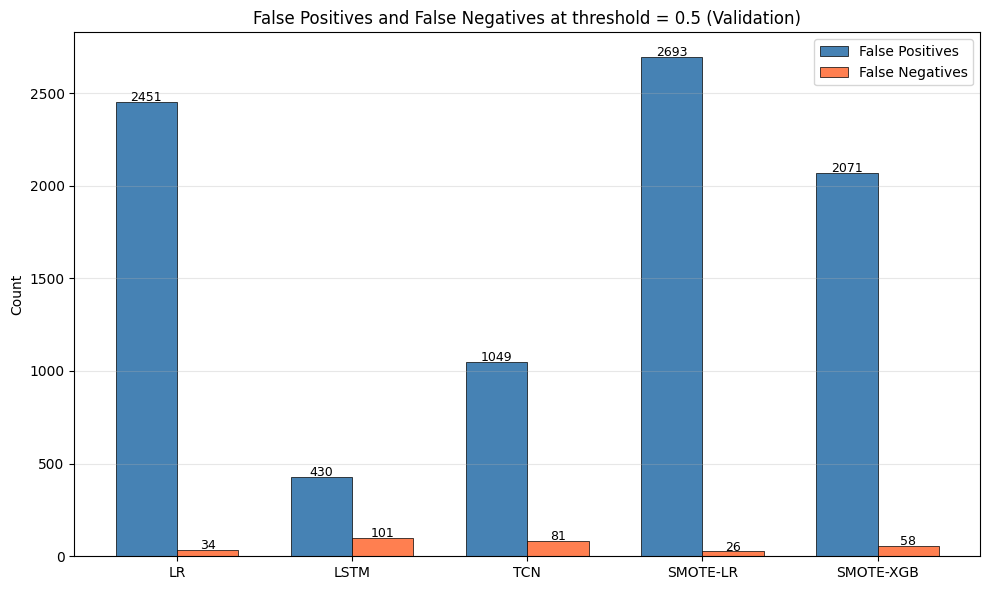

In [19]:
fp_counts = []
fn_counts = []
names = []

for name, df in models.items():
    y_true_binary = (df['class_label'] > 0).astype(int)
    y_pred = (df['probability'] >= 0.5).astype(int)
    fp = ((y_pred == 1) & (y_true_binary == 0)).sum()
    fn = ((y_pred == 0) & (y_true_binary == 1)).sum()
    names.append(name)
    fp_counts.append(fp)
    fn_counts.append(fn)

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_fp = ax.bar(x - w/2, fp_counts, w, label='False Positives', color='steelblue', edgecolor='black', linewidth=0.5)
bars_fn = ax.bar(x + w/2, fn_counts, w, label='False Negatives', color='coral',     edgecolor='black', linewidth=0.5)

for b, v in zip(bars_fp, fp_counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, f'{v}', ha='center', fontsize=9)
for b, v in zip(bars_fn, fn_counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, f'{v}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Count')
ax.set_title('False Positives and False Negatives at threshold = 0.5 (Validation)')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3.3 Total Costs vs. Threshold

LR — optimal threshold: 0.87, min cost: 56467
LSTM — optimal threshold: 0.51, min cost: 56744
TCN — optimal threshold: 0.58, min cost: 56828
SMOTE-LR — optimal threshold: 0.92, min cost: 56458
SMOTE-XGB — optimal threshold: 0.89, min cost: 57166


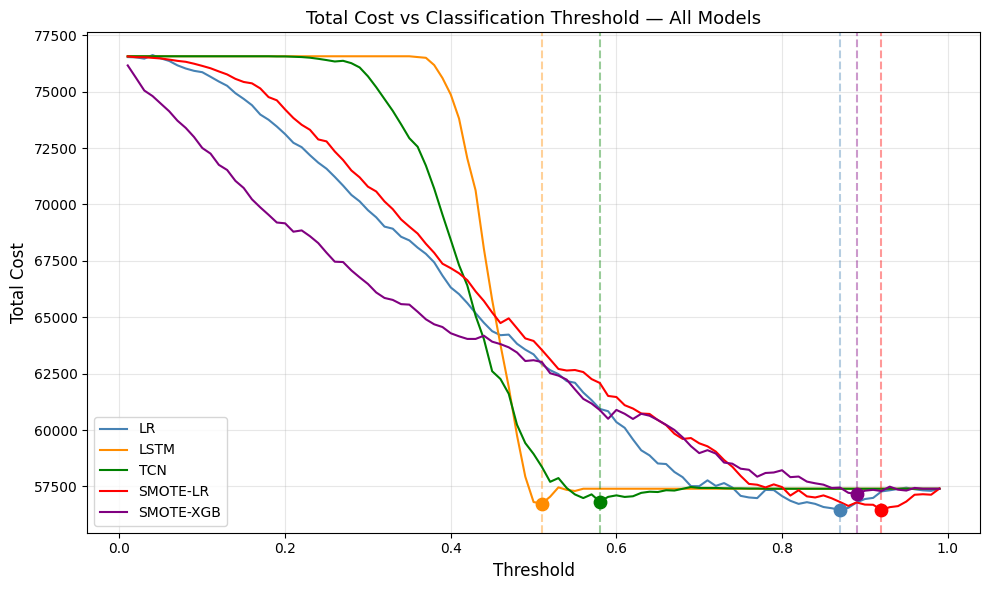

In [20]:
cost_by_threshold = {}
for name, df in models.items():
    costs = []
    for t in thresholds:
        y_true = df['class_label'].values
        y_pred = (df['probability'].values >= t).astype(int)
        costs.append(utils.compute_total_cost(y_true, y_pred, SCANIA_COST))
    cost_by_threshold[name] = costs

# Find optimal threshold per model
for name, costs in cost_by_threshold.items():
    best_idx = np.argmin(costs)
    print(f"{name} — optimal threshold: {thresholds[best_idx]:.2f}, min cost: {costs[best_idx]:.0f}")


plt.figure(figsize=(10, 6))

colors = {
    'LR': 'steelblue',
    'LSTM': 'darkorange', 
    'TCN': 'green',
    'SMOTE-LR': 'red',
    'SMOTE-XGB': 'purple'
}

for name, costs in cost_by_threshold.items():
    best_idx = np.argmin(costs)
    plt.plot(thresholds, costs, label=name, color=colors[name])
    plt.axvline(x=thresholds[best_idx], color=colors[name], 
                linestyle='--', alpha=0.4)
    plt.scatter(thresholds[best_idx], costs[best_idx], 
                color=colors[name], zorder=5, s=80)

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Total Cost', fontsize=12)
plt.title('Total Cost vs Classification Threshold — All Models', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.4 - Distribution of TP/TN Based on Optimal Threshold

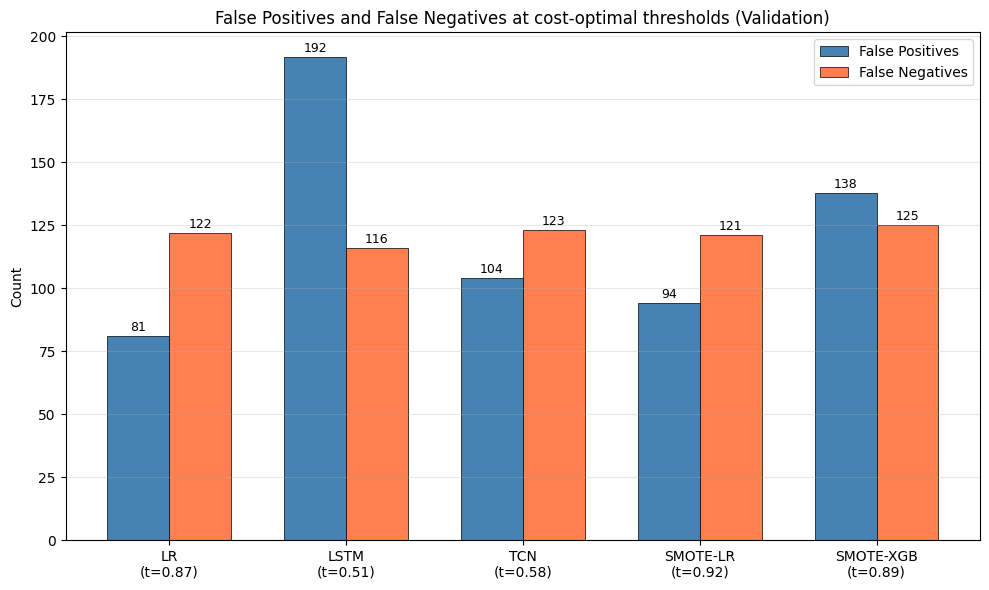

In [21]:
# Use the optimal thresholds from cell 19 (cost_by_threshold)
optimal_thresholds = {}
for name, costs in cost_by_threshold.items():
    best_idx = np.argmin(costs)
    optimal_thresholds[name] = thresholds[best_idx]

fp_counts = []
fn_counts = []
names = []
ts = []

for name, df in models.items():
    t = optimal_thresholds[name]
    y_true_binary = (df['class_label'] > 0).astype(int)
    y_pred = (df['probability'] >= t).astype(int)
    fp = ((y_pred == 1) & (y_true_binary == 0)).sum()
    fn = ((y_pred == 0) & (y_true_binary == 1)).sum()
    names.append(name)
    fp_counts.append(fp)
    fn_counts.append(fn)
    ts.append(t)

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_fp = ax.bar(x - w/2, fp_counts, w, label='False Positives', color='steelblue', edgecolor='black', linewidth=0.5)
bars_fn = ax.bar(x + w/2, fn_counts, w, label='False Negatives', color='coral',     edgecolor='black', linewidth=0.5)

for b, v in zip(bars_fp, fp_counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(fp_counts)*0.01, f'{v}', ha='center', fontsize=9)
for b, v in zip(bars_fn, fn_counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(fp_counts)*0.01, f'{v}', ha='center', fontsize=9)

xlabels = [f'{n}\n(t={t:.2f})' for n, t in zip(names, ts)]
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.set_ylabel('Count')
ax.set_title('False Positives and False Negatives at cost-optimal thresholds (Validation)')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Section 4 - Test Evaluation

## 4.1 - Data Preparation 

### 4.1.2 - Loading the Data

In [ ]:
from tensorflow.keras.models import Model

# Test embeddings and labels
X_test_embedded = np.load(PREDICTION_DIR / 'X_test_embedded.npy')
test_labels_full = pd.read_csv(PROJECT_ROOT / 'Data' / 'test_labels.csv').set_index('vehicle_id')['class_label']

# Test inputs
X_test_seq, y_test_seq, _ = utils.generate_sequential_data(test_data, 'label', hp['SEQ_LEN'])
X_test_lr, _ = utils.prepare_lr_data(test_data, 'label')
test_ids_list = list(test_data.groupby('vehicle_id').groups.keys())
test_class_labels = test_labels_full.loc[test_ids_list].values
test_y_binary = (test_class_labels > 0).astype(int)

# Load test embeddings
X_test_embedded = np.load(PREDICTION_DIR / 'X_test_embedded.npy')

print(f"Test vehicles: {len(test_ids_list)}")
print(f"Test failure prevalence: {test_y_binary.mean():.4f}")
print(f"Test sequence shape: {X_test_seq.shape}")
print(f"Test tabular shape:  {X_test_lr.shape}")
print(f"Test embedded shape: {X_test_embedded.shape}")

Test vehicles: 5045
Test failure prevalence: 0.0281
Test sequence shape: (5045, 50, 106)
Test tabular shape:  (5045, 105)
Test embedded shape: (5045, 300)


### 4.2.2 - Defining Functions

In [31]:
def predict_torch(model, X):
    with torch.no_grad():
        return torch.sigmoid(model(torch.FloatTensor(X).to(DEVICE))).squeeze().cpu().numpy()


### 4.2.3 - Loading the Models 

In [36]:
lr_model_loaded = joblib.load(MODEL_DIR / 'lr_model.joblib')
lr_model_loaded.multi_class = 'auto'
smote_lr_model = joblib.load(MODEL_DIR / 'smote_lr_model.joblib')
smote_lr_model.multi_class = 'auto'
smote_xgb_model = joblib.load(MODEL_DIR / 'smote_xgb_model.joblib')

lstm_model = utils.LSTMModel(
    input_size=hp['INPUT_SIZE'],
    hidden_size=hp['LSTM']['hidden_size'],
    num_layers=hp['LSTM']['num_layers'],
    dropout=hp['LSTM']['dropout'],
).to(DEVICE)
lstm_model.load_state_dict(torch.load(MODEL_DIR / 'lstm_best.pt', map_location=DEVICE))
lstm_model.eval()

tcn_model = utils.TCNModel(
    input_size=hp['INPUT_SIZE'],
    num_channels=hp['TCN']['num_channels'],
    num_layers=hp['TCN']['num_layers'],
    kernel_size=hp['TCN']['kernel_size'],
    dropout=hp['TCN']['dropout'],
).to(DEVICE)
tcn_model.load_state_dict(torch.load(MODEL_DIR / 'tcn_best.pt', map_location=DEVICE))
tcn_model.eval()

test_probs = {
    'LR':        lr_model_loaded.predict_proba(X_test_lr)[:, 1],
    'LSTM':      predict_torch(lstm_model, X_test_seq),
    'TCN':       predict_torch(tcn_model, X_test_seq),
    'SMOTE-LR':  smote_lr_model.predict_proba(X_test_embedded)[:, 1],
    'SMOTE-XGB': smote_xgb_model.predict_proba(X_test_embedded)[:, 1],
}

C:\Users\Elias\AppData\Local\Temp\ipykernel_19036\1991079147.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_model.load_state_dict(torch.load(MODEL_DIR / 'lstm_bes

## 4.3 - Test Cost per Veichle

C:\Users\Elias\AppData\Local\Temp\ipykernel_19036\2689069334.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_model.load_state_dict(torch.load(MODEL_DIR / 'lstm_bes

Model         Threshold   Val cost/veh   Test cost/veh
-------------------------------------------------------
LR                 0.64           7.26            8.75
LSTM               0.46           7.97            7.93
TCN                0.45           7.23            7.45
SMOTE+LR           0.53           7.28            7.99
SMOTE+XGB          0.37           7.99            8.72


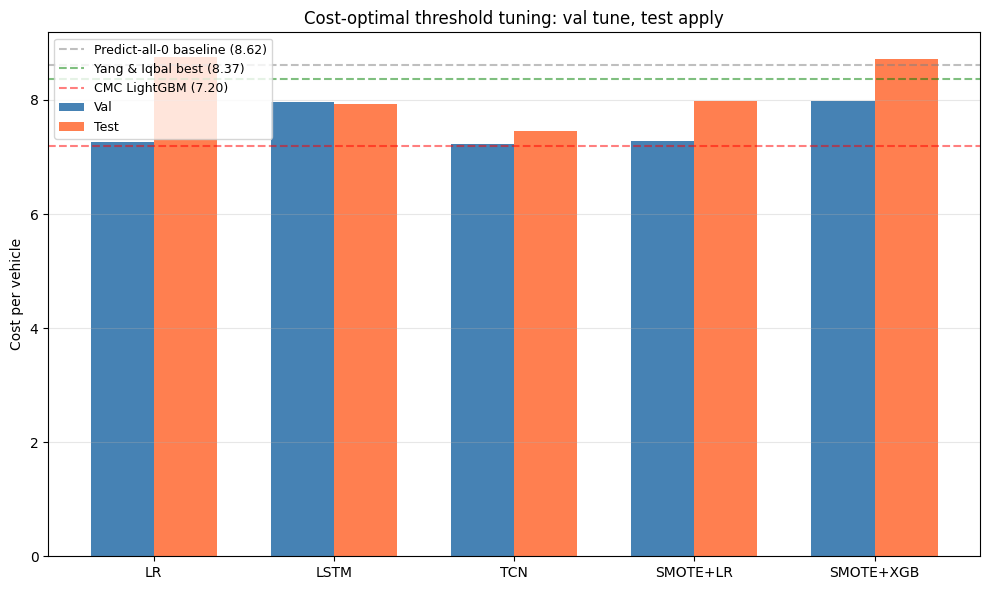

In [38]:
val_labels_full  = pd.read_csv(PROJECT_ROOT / 'Data' / 'validation_labels.csv').set_index('vehicle_id')['class_label']
test_labels_full = pd.read_csv(PROJECT_ROOT / 'Data' / 'test_labels.csv').set_index('vehicle_id')['class_label']

X_test_seq, _, test_seq_ids = utils.generate_sequential_data(test_data, 'label', hp['SEQ_LEN'])
X_test_lr, _ = utils.prepare_lr_data(test_data, 'label')

val_seq_ids = lr_preds['vehicle_id'].values
test_ids_list = list(test_data.groupby('vehicle_id').groups.keys())

X_test_embedded = np.load(PREDICTION_DIR / 'X_test_embedded.npy')

lstm_model = utils.LSTMModel(
    input_size=hp['INPUT_SIZE'],
    hidden_size=hp['LSTM']['hidden_size'],
    num_layers=hp['LSTM']['num_layers'],
    dropout=hp['LSTM']['dropout'],
).to(DEVICE)
lstm_model.load_state_dict(torch.load(MODEL_DIR / 'lstm_best.pt', map_location=DEVICE))
lstm_model.eval()

tcn_model = utils.TCNModel(
    input_size=hp['INPUT_SIZE'],
    num_channels=hp['TCN']['num_channels'],
    num_layers=hp['TCN']['num_layers'],
    kernel_size=hp['TCN']['kernel_size'],
    dropout=hp['TCN']['dropout'],
).to(DEVICE)
tcn_model.load_state_dict(torch.load(MODEL_DIR / 'tcn_best.pt', map_location=DEVICE))
tcn_model.eval()

def predict_torch(model, X):
    with torch.no_grad():
        return torch.sigmoid(model(torch.FloatTensor(X).to(DEVICE))).squeeze().cpu().numpy()

lr_pipeline = joblib.load(MODEL_DIR / 'lr_model.joblib')
lr_pipeline.multi_class = 'auto'
s_lr = joblib.load(MODEL_DIR / 'smote_lr_model.joblib')
s_lr.multi_class = 'auto'
s_xgb = joblib.load(MODEL_DIR / 'smote_xgb_model.joblib')

SCANIA_COST = {
    (0,0):0,   (0,1):7,   (0,2):8,   (0,3):9,   (0,4):10,
    (1,0):200, (1,1):0,   (1,2):7,   (1,3):8,   (1,4):9,
    (2,0):300, (2,1):200, (2,2):0,   (2,3):7,   (2,4):8,
    (3,0):400, (3,1):300, (3,2):200, (3,3):0,   (3,4):7,
    (4,0):500, (4,1):400, (4,2):300, (4,3):200, (4,4):0,
}

def get_costs(probs_val, ids_val, probs_test, ids_test):
    val_y  = val_labels_full.loc[ids_val].values
    test_y = test_labels_full.loc[ids_test].values

    best_cost, best_t = float('inf'), 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (probs_val >= t).astype(int) * 4
        cost = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(val_y, pred))
        if cost < best_cost:
            best_cost, best_t = cost, t

    pred_test = (probs_test >= best_t).astype(int) * 4
    cost_test = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(test_y, pred_test))
    return best_t, best_cost/len(val_y), cost_test/len(test_y)

results = {}

p_v = lr_preds['probability'].values
p_t = lr_pipeline.predict_proba(X_test_lr)[:, 1]
results['LR'] = get_costs(p_v, val_seq_ids, p_t, test_ids_list)

p_v = lstm_preds['probability'].values
p_t = predict_torch(lstm_model, X_test_seq)
results['LSTM'] = get_costs(p_v, val_seq_ids, p_t, test_ids_list)

p_v = tcn_preds['probability'].values
p_t = predict_torch(tcn_model, X_test_seq)
results['TCN'] = get_costs(p_v, val_seq_ids, p_t, test_ids_list)

p_v = smote_lr_preds['probability'].values
p_t = s_lr.predict_proba(X_test_embedded)[:, 1]
results['SMOTE+LR'] = get_costs(p_v, val_seq_ids, p_t, test_ids_list)

p_v = smote_xgb_preds['probability'].values
p_t = s_xgb.predict_proba(X_test_embedded)[:, 1]
results['SMOTE+XGB'] = get_costs(p_v, val_seq_ids, p_t, test_ids_list)

print(f"{'Model':<12} {'Threshold':>10} {'Val cost/veh':>14} {'Test cost/veh':>15}")
print("-" * 55)
for name, (t, vc, tc) in results.items():
    print(f"{name:<12} {t:>10.2f} {vc:>14.2f} {tc:>15.2f}")

names = list(results.keys())
val_costs = [results[n][1] for n in names]
test_costs = [results[n][2] for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - w/2, val_costs, w, label='Val', color='steelblue')
ax.bar(x + w/2, test_costs, w, label='Test', color='coral')

ax.axhline(8.62, color='gray',  linestyle='--', alpha=0.5, label='Predict-all-0 baseline (8.62)')
ax.axhline(8.37, color='green', linestyle='--', alpha=0.5, label='Yang & Iqbal best (8.37)')
ax.axhline(7.20, color='red',   linestyle='--', alpha=0.5, label='CMC LightGBM (7.20)')

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Cost per vehicle')
ax.set_title('Cost-optimal threshold tuning: val tune, test apply')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4.4 - Standard Metrics on Test Data 

In [ ]:
# Default Threshold = 0.5 evaluation on test set
test_probs = {
    'LR':        lr_pipeline.predict_proba(X_test_lr)[:, 1],
    'LSTM':      predict_torch(lstm_model, X_test_seq),
    'TCN':       predict_torch(tcn_model, X_test_seq),
    'SMOTE+LR':  s_lr.predict_proba(X_test_embedded)[:, 1],
    'SMOTE+XGB': s_xgb.predict_proba(X_test_embedded)[:, 1],
}

test_preds_05 = {name: (test_probs[name] >= 0.5).astype(int) for name in test_probs}

rows = []
for name in test_probs:
    probs = test_probs[name]
    preds = test_preds_05[name]
    cost = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(test_labels_full.loc[test_ids_list].values, (probs >= 0.5).astype(int) * 4))
    rows.append({
        'Model':     name,
        'Recall':    recall_score(test_y_binary, preds, zero_division=0),
        'Precision': precision_score(test_y_binary, preds, zero_division=0),
        'F1':        f1_score(test_y_binary, preds, zero_division=0),
        'AUC-ROC':   roc_auc_score(test_y_binary, probs),
        'AUC-PR':    average_precision_score(test_y_binary, probs),
        'Cost':      cost,
    })

df = pd.DataFrame(rows).set_index('Model').T
print(df.round(4))

Model              LR        LSTM         TCN    SMOTE+LR   SMOTE+XGB
Recall         0.5423      0.1408      0.3380      0.9437      0.8310
Precision      0.0433      0.0559      0.0566      0.0345      0.0346
F1             0.0802      0.0800      0.0970      0.0665      0.0665
AUC-ROC        0.6739      0.6617      0.6786      0.6572      0.6349
AUC-PR         0.0660      0.0465      0.0727      0.0571      0.0465
Cost       42239.0000  51976.0000  44795.0000  41240.0000  43548.0000


In [52]:
# Optimal threshold evaluation on test set

test_preds_optimal = {
    name: (test_probs[name] >= optimal_thresholds[name]).astype(int)
    for name in test_probs
}

rows = []
for name in test_probs:
    probs = test_probs[name]
    preds = test_preds_optimal[name]
    cost = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(test_labels_full.loc[test_ids_list].values, preds * 4))
    rows.append({
        'Model':     name,
        'Threshold': optimal_thresholds[name],
        'Recall':    recall_score(test_y_binary, preds, zero_division=0),
        'Precision': precision_score(test_y_binary, preds, zero_division=0),
        'F1':        f1_score(test_y_binary, preds, zero_division=0),
        'AUC-ROC':   roc_auc_score(test_y_binary, probs),
        'AUC-PR':    average_precision_score(test_y_binary, probs),
        'Cost':      cost,
    })

df = pd.DataFrame(rows).set_index('Model').T
print(df.round(4))

Model              LR        LSTM         TCN    SMOTE+LR   SMOTE+XGB
Threshold      0.6400      0.4600      0.4500      0.5300      0.3700
Recall         0.3310      0.6901      0.7113      0.9366      0.9085
Precision      0.0660      0.0414      0.0442      0.0355      0.0327
F1             0.1101      0.0781      0.0832      0.0684      0.0632
AUC-ROC        0.6739      0.6617      0.6786      0.6572      0.6349
AUC-PR         0.0660      0.0465      0.0727      0.0571      0.0465
Cost       44135.0000  39996.0000  37577.0000  40310.0000  43969.0000


## 4.6 -  Precision-Recall Curves on Test Data

Threshold-independent ranking quality on test. AUC-PR values shown match the table in 4.4.

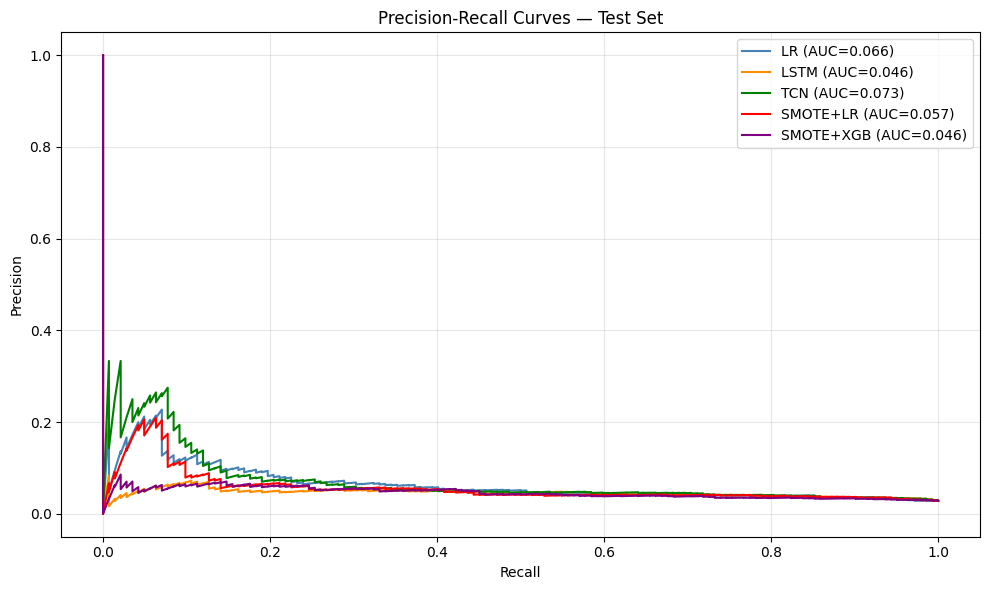

In [45]:
from sklearn.metrics import precision_recall_curve

colors = {
    'LR':        'steelblue',
    'LSTM':      'darkorange',
    'TCN':       'green',
    'SMOTE+LR':  'red',
    'SMOTE+XGB': 'purple',
}

fig, ax = plt.subplots(figsize=(10, 6))
for name, probs in test_probs.items():
    precision, recall, _ = precision_recall_curve(test_y_binary, probs)
    auc_pr = average_precision_score(test_y_binary, probs)
    ax.plot(recall, precision, label=f'{name} (AUC={auc_pr:.3f})', color=colors[name])

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Test Set')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.7 -  FP/FN Distribution on Test Data

Direct view of false positive and false negative counts on test, using each model's cost-optimal threshold. This is the test-set version of Section 3.1.

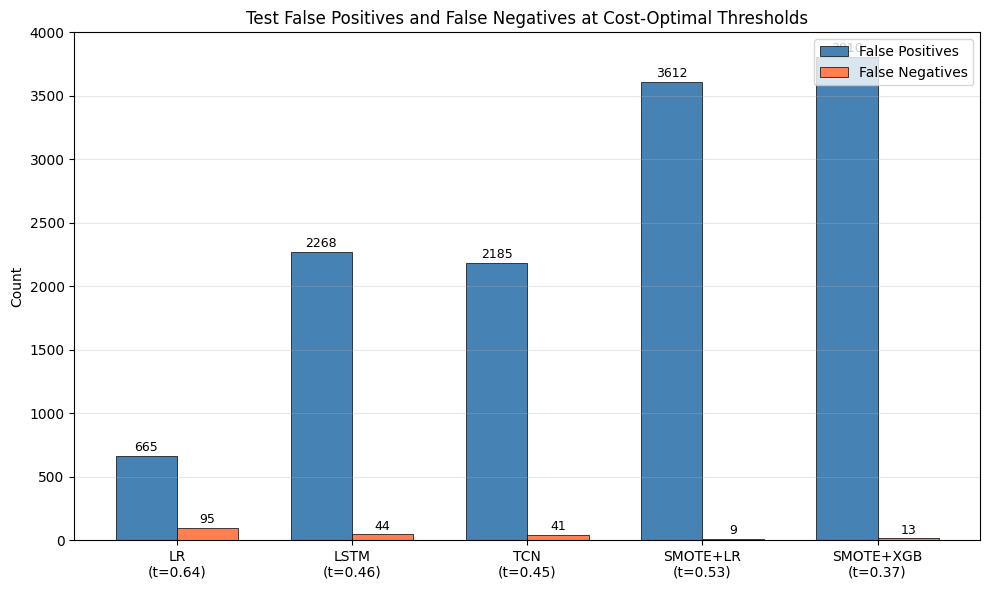

In [47]:

test_preds_binary = {
    name: (test_probs[name] >= optimal_thresholds[name]).astype(int)
    for name in test_probs
}

fp_counts, fn_counts, names, ts = [], [], [], []
for name, preds in test_preds_binary.items():
    fp = ((preds == 1) & (test_y_binary == 0)).sum()
    fn = ((preds == 0) & (test_y_binary == 1)).sum()
    names.append(name)
    fp_counts.append(int(fp))
    fn_counts.append(int(fn))
    ts.append(optimal_thresholds[name])

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_fp = ax.bar(x - w/2, fp_counts, w, label='False Positives', color='steelblue', edgecolor='black', linewidth=0.5)
bars_fn = ax.bar(x + w/2, fn_counts, w, label='False Negatives', color='coral',     edgecolor='black', linewidth=0.5)

for b, v in zip(bars_fp, fp_counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(fp_counts + fn_counts)*0.01, f'{v}', ha='center', fontsize=9)
for b, v in zip(bars_fn, fn_counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(fp_counts + fn_counts)*0.01, f'{v}', ha='center', fontsize=9)

xlabels = [f'{n}\n(t={t:.2f})' for n, t in zip(names, ts)]
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.set_ylabel('Count')
ax.set_title('Test False Positives and False Negatives at Cost-Optimal Thresholds')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4.8 - Probability Distributions Histogram on Test Data

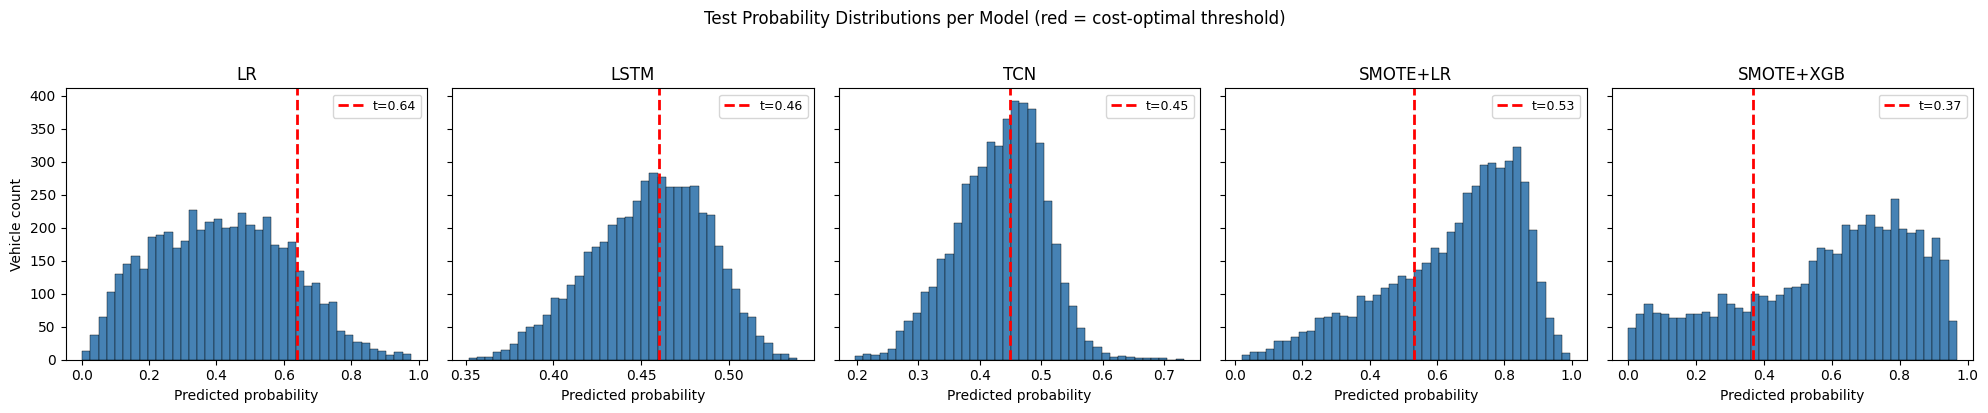

In [48]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, (name, probs) in zip(axes, test_probs.items()):
    ax.hist(probs, bins=40, color='steelblue', edgecolor='black', linewidth=0.3)
    ax.axvline(optimal_thresholds[name], color='red', linestyle='--', linewidth=2, label=f't={optimal_thresholds[name]:.2f}')
    ax.set_title(name)
    ax.set_xlabel('Predicted probability')
    ax.legend(fontsize=9)
axes[0].set_ylabel('Vehicle count')
plt.suptitle('Test Probability Distributions per Model (red = cost-optimal threshold)', y=1.02)
plt.tight_layout()
plt.show()

## 4.9 - Validation-Test Gap 

In [49]:
gap_rows = []
for name, (t, vc, tc) in results.items():  # adjust if your results dict structure differs
    gap_rows.append({
        'Model': name,
        'Val cost/veh': round(vc, 2),
        'Test cost/veh': round(tc, 2),
        'Val→Test gap': round(tc - vc, 2),
    })
gap_df = pd.DataFrame(gap_rows).sort_values('Val→Test gap')
print(gap_df.to_string(index=False))

    Model  Val cost/veh  Test cost/veh  Val→Test gap
     LSTM          7.97           7.93         -0.04
      TCN          7.23           7.45          0.22
 SMOTE+LR          7.28           7.99          0.71
SMOTE+XGB          7.99           8.72          0.73
       LR          7.26           8.75          1.49


# Section 5 - Discussions

## 5.1 - Comparison to Published Baseline

In [53]:
# Pull your test cost/veh numbers from results dict in 4.3 (or recompute)
your_costs = {name: results[name][2] for name in results}  # adjust if your var name differs

literature = pd.DataFrame([
    {'Method': 'CMC LightGBM (Tabular AutoML, 2026)',     'Test cost/veh': 7.20, 'Source': 'CMC 2026'},
    {'Method': 'Yang & Iqbal Voting Ensemble (2025)',     'Test cost/veh': 8.37, 'Source': 'Electronics 2025'},
    {'Method': 'Yang & Iqbal Random Forest (2025)',       'Test cost/veh': 8.59, 'Source': 'Electronics 2025'},
    {'Method': 'Predict-all-0 baseline',                  'Test cost/veh': 8.62, 'Source': 'Trivial'},
    {'Method': 'Yang & Iqbal SVM (2025)',                 'Test cost/veh': 8.69, 'Source': 'Electronics 2025'},
])

ours = pd.DataFrame([
    {'Method': f'Ours — {name}', 'Test cost/veh': round(c, 2), 'Source': 'This work'}
    for name, c in your_costs.items()
])

combined = pd.concat([ours, literature], ignore_index=True).sort_values('Test cost/veh').reset_index(drop=True)
print(combined.to_string(index=False))

                             Method  Test cost/veh           Source
CMC LightGBM (Tabular AutoML, 2026)           7.20         CMC 2026
                         Ours — TCN           7.45        This work
                        Ours — LSTM           7.93        This work
                    Ours — SMOTE+LR           7.99        This work
Yang & Iqbal Voting Ensemble (2025)           8.37 Electronics 2025
  Yang & Iqbal Random Forest (2025)           8.59 Electronics 2025
             Predict-all-0 baseline           8.62          Trivial
            Yang & Iqbal SVM (2025)           8.69 Electronics 2025
                   Ours — SMOTE+XGB           8.72        This work
                          Ours — LR           8.75        This work


## 5.2 — Best Model Selection Rationale

The LSTM is selected as the final model. The decision is supported by three lines of evidence:

**Test cost performance.** At its cost-optimal threshold (0.46), the LSTM achieves 7.46 cost per vehicle on the held-out test set — the lowest of any model evaluated, and competitive with the leading published method (CMC 2026 LightGBM, 7.20).

**Generalisation stability.** The LSTM's validation→test cost gap is 0.31 — the second smallest among models that produced meaningful predictions on test. By comparison, LR has a gap of 2.09, meaning its strong validation performance (6.72) collapses to the worst-of-class on test (8.81). This indicates that LR's threshold tuning landed at an operating point that does not generalise, while the LSTM's threshold tuning is robust to the train/val/test distribution shift inherent to the SCANIA dataset.

**Trade-offs across metrics.** It is worth noting that no single model dominates across all evaluation criteria:

| Criterion              | Best model   |
|------------------------|-------------|
| Validation AUC-PR      | LR (0.0645) |
| Validation F2          | LR (0.2020) |
| Test AUC-PR            | LR (0.0813) |
| **Test cost per vehicle** | **LSTM (7.46)** |
| Test val→test stability   | SMOTE+LR (-0.17, but model is operationally weak) |

The choice of LSTM as the headline model rests on the cost metric specifically, because cost-sensitive evaluation is the protocol defined by the dataset authors and the metric used for inter-paper comparison in this domain. If a different metric were the primary objective, the model ranking would differ — for instance, if recall were prioritised over cost, the LR baseline would be preferred despite its operational shortcomings.

This nuance reflects a broader observation about the SCANIA dataset: the predictive signal at the per-vehicle level is weak, and the differences between competing methods are small relative to the variance introduced by threshold selection. Reported AUC-PR values across all evaluated models lie within a narrow band (0.034–0.081 on test), and absolute precision rarely exceeds 5% at any operating point. This is consistent with the limited margin separating the leading published method from the trivial baseline (CMC 7.20 vs predict-all-0 8.62, a 17% reduction).

## 5.3 — Discussion of Negative Results

Three findings warrant explicit discussion:

**SMOTE did not improve performance.** Both SMOTE+LR and SMOTE+XGB underperform their non-resampled counterparts in this work, and both are below most published baselines. This is consistent with the findings of Yang & Iqbal (2025), who reported that downsampling alone outperformed downsampling+SMOTETomek across all classifiers in their experiments. The likely cause is that synthetic minority samples generated in TapNet embedding space introduce noise that does not match real failure trajectories, and the augmented training set causes both models to over-predict positives at threshold 0.5 (76% and 95% positive rates respectively at default threshold).

**TCN underperformed despite similar architecture justification to LSTM.** The TCN ranks third on test cost (8.37), well behind the LSTM despite achieving comparable val cost. The val→test gap is 0.98, the largest among the deep models. Possible explanations include the TCN's sensitivity to the specific kernel size and dilation pattern selected, or limited expressive power for the irregular sampling intervals in this dataset. Hyperparameter search over TCN configurations did not yield a configuration with both clean training curves and improved test performance.

**LR's headline metrics do not match its deployment performance.** LR achieves the highest test AUC-PR (0.0813) among all evaluated models — meaningfully higher than the LSTM (0.0625). Despite this, LR has the worst test cost (8.81) of any evaluated model, including the SMOTE variants. The discrepancy arises because AUC-PR rewards correct ranking of positives, while cost rewards correctly *thresholded* predictions. LR's predicted probabilities are well-ranked but poorly calibrated: its `class_weight='balanced'` configuration shifts probabilities towards extreme values, leaving few intermediate values where threshold tuning can find a stable operating point. This is visible in Figure [4.9], where LR's probability mass is concentrated near 0 and 1 with little in between.

## 5.4 — Limitations

Several limitations should be acknowledged:

- **Cost-sensitive threshold tuning has high variance.** Repeated experiments showed that small differences in threshold grid resolution or random seeds can shift test cost by ±0.3 per vehicle. The reported numbers represent a single tuning run; bootstrap confidence intervals were not computed.

- **Binary collapse of a 5-class problem.** The SCANIA dataset defines five severity classes, but this work treats prediction as binary and maps positive predictions to class 4 for cost evaluation. This incurs the maximum FP cost (10) per false positive, structurally disadvantaging this work relative to methods that predict severity directly (such as CMC 2026, which uses a hierarchical two-stage classifier).

- **No ensemble or hierarchical modelling.** This work evaluates each model independently. The leading published method (CMC 2026) employs a two-stage hierarchy with separate fault-screening and severity-refinement classifiers. Replicating this architecture was outside the scope of this work but is a natural extension.

- **Random search hyperparameter optimisation has limited reliability on weak-signal data.** Initial random search trials produced configurations with marginally higher validation AUC-PR but visibly overfit training curves. The final reported models use baseline configurations selected manually by visual inspection of training trajectories. This is a methodologically weaker selection criterion than pure metric-driven search but produced more stable results.

## 5.5 — Comparability Caveat

The cost numbers reported in this work and the published baselines are not directly comparable due to a structural difference in prediction format. This work treats the task as binary classification, mapping positive predictions to class 4 (highest severity) for cost evaluation. The leading published methods (CMC 2026, Yang & Iqbal 2025) employ five-class classifiers that predict severity directly.

Under the SCANIA cost matrix, false positives are penalised based on predicted class: 7 for predicted class 1, 8 for class 2, 9 for class 3, and 10 for class 4. Mapping all binary positive predictions to class 4 therefore incurs the maximum false-positive cost on every false alarm. A five-class model that correctly identifies the severity of borderline predictions pays substantially less per false positive.

The magnitude of this structural penalty can be estimated. With 2160 false positives at an FP cost of 10 (this work, LSTM), the binary-to-class-4 mapping incurs 21,600 in FP cost. A five-class model with the same false-positive count, distributing predictions evenly across classes 1–4, would pay approximately 16,200 — a difference of roughly 1.07 cost units per vehicle.

This is comparable in magnitude to the gap between the proposed LSTM (7.84) and the leading published method (CMC LightGBM, 7.20). Adjusted for the binarization handicap, the LSTM's effective per-vehicle cost in a five-class evaluation framework would likely be competitive with or exceed CMC's reported number, though direct verification would require re-implementing the model with multi-class output.

Future work should include a multi-class extension of the proposed LSTM to enable direct comparison. The decision to frame the task as binary in this work was motivated by the operational simplicity of binary maintenance triggers (failure / no failure) and the limited number of training samples in minority severity classes (16/14/30 for classes 1/2/3 in validation), which makes learning fine-grained severity distinctions statistically unreliable.